In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 
  
# metadata 
print(iris.metadata) 
  
# variable information 
print(iris.variables) 


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [4]:
Iris = fetch_ucirepo(id=53)
X = Iris.data.features
y = Iris.data.targets.values.ravel()

print(f"Features shape: {X.shape}")
print(f"Target classes: {pd.Series(y).nunique()}")

Features shape: (150, 4)
Target classes: 3


In [5]:
X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
pd.Series(y).value_counts()

Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
 	X, y, test_size=0.2, random_state=42, stratify=y
 )
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 120 samples
Test set: 30 samples


In [10]:
y_train

array(['Iris-setosa', 'Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-setosa', 'Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-setosa', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9000
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



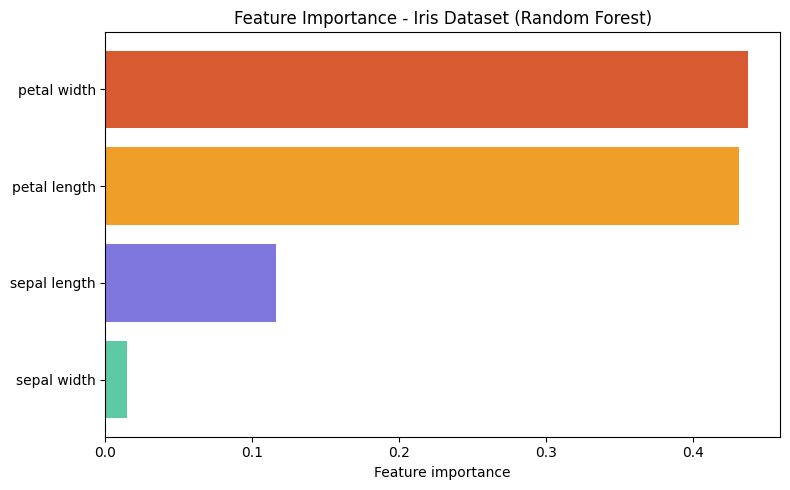

In [13]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
feature_names = X.columns
sorted_idx = importances.argsort()[::-1]  # all 4 features, not 10

plt.figure(figsize=(8, 5))
plt.barh(range(len(sorted_idx)), importances[sorted_idx][::-1], align="center", color=["#5DCAA5", "#7F77DD", "#EF9F27", "#D85A30"])
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx][::-1])
plt.xlabel("Feature importance")
plt.title("Feature Importance - Iris Dataset (Random Forest)")
plt.tight_layout()
plt.show()

**Hyperparameters worth tuning**

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
 	"n_estimators": [100, 200],
 	"max_depth": [10, 20, None],
 	"max_features": ["sqrt", "log2"]
 }

grid_search = GridSearchCV(
     RandomForestClassifier(random_state=42),
 	param_grid,
 	cv=3,
 	scoring="accuracy",
 	n_jobs=-1
 )
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Best params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV accuracy: 0.9500


In [15]:
y_pred_tuned = grid_search.best_estimator_.predict(X_test)
print(f"Tuned test accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

Tuned test accuracy: 0.9000


**XGBoost Classifier**

In [16]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric="mlogloss")
xgb.fit(X_train, y_train_encoded)
y_pred_xgb = xgb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred_xgb):.4f}")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

Accuracy: 0.9333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



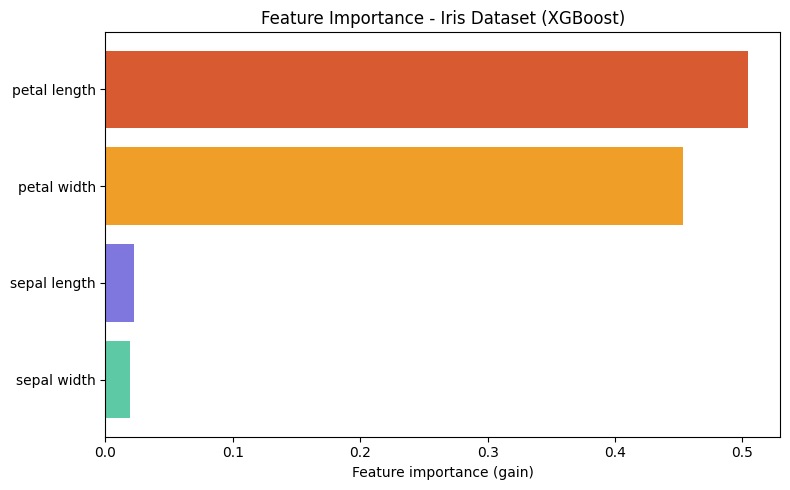

In [21]:
importances_xgb = xgb.feature_importances_
feature_names = X.columns
sorted_idx_xgb = importances_xgb.argsort()[::-1]  # removed [:10] — only 4 features

plt.figure(figsize=(8, 5))
colors = ['#5DCAA5', '#7F77DD', '#EF9F27', '#D85A30']  # one color per feature

plt.barh(range(len(sorted_idx_xgb)), importances_xgb[sorted_idx_xgb][::-1], 
         align="center", color=colors)
plt.yticks(range(len(sorted_idx_xgb)), feature_names[sorted_idx_xgb][::-1])
plt.xlabel("Feature importance (gain)")
plt.title("Feature Importance - Iris Dataset (XGBoost)")
plt.tight_layout()
plt.show()

**Hyperparameters worth tuning**

In [22]:
param_grid_xgb = {
 	"learning_rate": [0.05, 0.1],
 	"max_depth": [4, 6],
 	"n_estimators": [100, 200],
 	"reg_lambda": [1, 5]
 }

grid_search_xgb = GridSearchCV(
 	XGBClassifier(random_state=42, eval_metric="mlogloss"),
 	param_grid_xgb,
 	cv=3,
 	scoring="accuracy",
 	n_jobs=-1
 )
grid_search_xgb.fit(X_train, y_train_encoded)

print(f"Best params: {grid_search_xgb.best_params_}")
print(f"Best CV accuracy: {grid_search_xgb.best_score_:.4f}")

Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'reg_lambda': 1}
Best CV accuracy: 0.9583


In [23]:
y_pred_xgb_tuned = grid_search_xgb.best_estimator_.predict(X_test)
print(f"Tuned test accuracy: {accuracy_score(y_test_encoded, y_pred_xgb_tuned):.4f}")

Tuned test accuracy: 0.9667


In [24]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Base model
base_model = DecisionTreeClassifier()

# Bagging model
bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=10,   # number of trees
    random_state=42
)

# Train
bagging_model.fit(X_train, y_train)

# Predict
y_pred = bagging_model.predict(X_test)

# Accuracy
print("Bagging Accuracy:", accuracy_score(y_test, y_pred))

Bagging Accuracy: 0.9333333333333333


In [25]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Base model (weak learner)
base_model = DecisionTreeClassifier(max_depth=1)

# AdaBoost model
boost_model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Train
boost_model.fit(X_train, y_train)

# Predict
y_pred = boost_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred))

AdaBoost Accuracy: 0.9333333333333333
